In [1]:
import matplotlib as mpl
%matplotlib inline
# Set the font to Times New Roman or a similar serif font
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
# Adjust the text sizes
mpl.rcParams['axes.labelsize'] = 10  # For X and Y axis labels
mpl.rcParams['axes.titlesize'] = 10  # For the plot title
mpl.rcParams['legend.fontsize'] = 10 # For the legend


from utils import *

colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]

In [12]:
def plot_husimi_probability_contours(dressed_state,product_to_dressed,qubit_level,osc_level):
    if dressed_state.dims[-1][0] == 1:
        dressed_state = qutip.ket2dm(dressed_state)
    dressed_dm_data = dressed_state.full()
    rho_product = np.zeros((qubit_level * osc_level, qubit_level * osc_level), dtype=complex)
    for (ql, ol), dressed_level in product_to_dressed.items():
        index1 = ql * osc_level + ol
        # Loop again to populate the density matrix
        for (ql2, ol2), dressed_level2 in product_to_dressed.items():
            index2 = ql2 * osc_level + ol2
            # TODO  the order of product_state and product_state2 doesn't make sense to me, but it produces the right result. :(
            element = dressed_dm_data[dressed_level, dressed_level2]
            rho_product[index1, index2] += element
    rho_product = qutip.Qobj(rho_product, dims=[[qubit_level, osc_level], [qubit_level, osc_level]])
    rho_coherent = rho_product.ptrace(1)

    # print(f"nonhermicity: abs(rho_coherent - rho_coherent.dag()).data.max() {abs(rho_coherent - rho_coherent.dag()).data.max()}")
    print(f"nonhermicity: Frobenius norm of the difference between rho and rho dag {np.linalg.norm((rho_coherent - rho_coherent.dag()).full(), 'fro')}")
    rho_coherent = 0.5 * (rho_coherent + rho_coherent.dag())

    print(f"trace: {rho_coherent.tr()}")
    rho_coherent = rho_coherent / rho_coherent.tr()


    xvec = np.linspace(-20,20,500)

    Q_coherent = qutip.qfunc(rho_coherent, xvec, xvec)

    q_values = Q_coherent
    sorted_q = np.sort(q_values.ravel())
    cumulative_sum = np.cumsum(sorted_q)
    total_sum = cumulative_sum[-1]
    X, Y = np.meshgrid(xvec, xvec)
    # for prob in [0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.05,0.02]:
    for prob in [0.9,0.5]:
        level_value = sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - prob))]
        contour = plt.contour(X, Y, q_values, levels=[level_value], colors=[(prob, 0, 0, 1)])
        fmt = {level_value:f'{1 - prob:.2f}'}
        plt.clabel(contour, inline=False, fontsize=6, fmt=fmt)

    # Q_coherent[Q_coherent < sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - 0.98))]] = None
    # plt.contourf(xvec, xvec, Q_coherent, 100)

nonhermicity: Frobenius norm of the difference between rho and rho dag 0.0007539575827052492
trace: 0.9999999999993049
nonhermicity: Frobenius norm of the difference between rho and rho dag 5.558165491413522e-07
trace: 1.000000000000176
nonhermicity: Frobenius norm of the difference between rho and rho dag 0.008739834496901652
trace: 0.9999999999997652
nonhermicity: Frobenius norm of the difference between rho and rho dag 0.0
trace: 0.9999999999996546
nonhermicity: Frobenius norm of the difference between rho and rho dag 1.1470135158190922e-05
trace: 1.0000000000007927
nonhermicity: Frobenius norm of the difference between rho and rho dag 1.4417001940136709e-05
trace: 1.0000000000007274


 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_64626/3762833401.py: 218

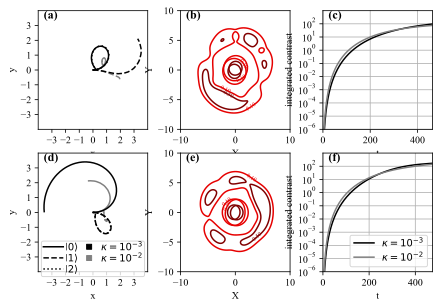

In [19]:
fig = plt.figure(figsize=((3+3/8)*1.4*1.5, 
                            (3+3/8)*1.4))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1,1], wspace=0.3)



#########################################################################################################
#
# Plotting the first row, about the 0-1 fluxonium
#
#########################################################################################################
tot_time =463
tlist = np.linspace(0, tot_time, tot_time)
qubit_level = 25
osc_level = 50
system = fluxonium_oscillator_system(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = 6.81289062,
    g_strength = 0.23,
    qubit_level = qubit_level,
    osc_level = osc_level,
    kappa = 1e-3,
    products_to_keep=[[ql, ol] for ql in [2] for ol in range(3) ],
    computaional_states = '0,1',
    )

with open('pickles/mesolve_01.pkl', 'rb') as file:
    results = pickle.load(file)
detection_results_1em3 = [results[0],results[1],results[2]]
detection_results_1em2 = [results[3],results[4],results[5]]
first_dominant_freq =find_dominant_frequency(results[1].expect[0],tlist)

ax = plt.subplot(gs[0,0])
plt.text(0.05, 1, '(a)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
for list_of_results,kappa,color in reversed(list(zip([detection_results_1em3,detection_results_1em2],
                                                     [r"10^{-3}",r"10^{-2}"],
                                                     ['black','gray']))):
    # different initial states has different line shape
    for i, linestype in zip([0,1,2],['-',':','--']):
        alpha = list_of_results[i].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
        line, = ax.plot(-alpha.imag,alpha.real,label=rf'$\left|{i}\right>,\kappa={kappa}$',color=color,linestyle=linestype)
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)
ax.set_xticks([-3,-2,-1,0,1,2,3])
ax.set_yticks([-3,-2,-1,0,1,2,3])

ax.set_xlabel('x')
ax.set_ylabel('y')


ax = plt.subplot(gs[0,1])
plt.text(0.05, 1, '(b)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
t_idx = tot_time-1
val = 0
for i in [0,1,2]:
    # alpha_list = detection_results_1em3[i].expect[-2]
    # alpha_rot_list = alpha_list * np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    # line, = plt.plot(-alpha_rot_list.imag,alpha_rot_list.real,label=rf'$\left|{i}\right>,\kappa={kappa}$',color=color,linestyle=linestype)
    # alpha_rot_list_reverse = alpha_list * np.exp(1j * 2 * np.pi * first_dominant_freq * tlist)
    val = plot_husimi_probability_contours(dressed_state=detection_results_1em3[i].states[t_idx],
                                    product_to_dressed=system.product_to_dressed,
                                    qubit_level = qubit_level,
                                    osc_level = osc_level,
                                    )


# ax.set_title("Probability Contours and values of the Husimi Q Function")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)


ax = plt.subplot(gs[0,2])
plt.text(0.05, 1, '(c)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
for list_of_results,kappa,kappa_val,color in zip([detection_results_1em3,detection_results_1em2],
                                                     ["10^{-3}",r"10^{-2}"],
                                                [1e-3,1e-2],
                                                ['black','gray']):
    alpha0 = list_of_results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alpha1 = list_of_results[2].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    squared_diff = np.square(abs(alpha0-alpha1))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                         (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                         )
        
    plt.plot(tlist,integrals,label=rf'$\kappa={kappa}$',color=color)

# ax.legend(loc='lower right')
ax.set_yscale('log')
ax.set_ylim(1e-6,1e3)
ax.set_yticks([1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
ax.set_xlim(0,tot_time)
ax.grid()
ax.set_xlabel('t')
ax.set_ylabel('integrated contrast')

#########################################################################################################
#
# Plotting the second row, about the 1-2 fluxonium
#
#########################################################################################################
tot_time =474
tlist = np.linspace(0, tot_time, tot_time)
qubit_level = 25
osc_level = 50
system = fluxonium_oscillator_system(
    EJ = 3,
    EC = 0.6,
    EL = 0.13,
    Er = 7.2622522,
    g_strength = 0.3,
    qubit_level = qubit_level,
    osc_level = osc_level,
    kappa = 1e-3,
    products_to_keep=[[ql, ol] for ql in [2] for ol in range(3) ],
    computaional_states = '1,2',
    )

with open('pickles/mesolve_12.pkl', 'rb') as file:
    results = pickle.load(file)
detection_results_1em3 = [results[0],results[1],results[2]]
detection_results_1em2 = [results[3],results[4],results[5]]
first_dominant_freq =find_dominant_frequency(results[1].expect[0],tlist)
black_line, = plt.plot([], [], marker="s", markersize=5, linewidth=0, color='black', linestyle='-')
gray_line, = plt.plot([], [], marker="s", markersize=5, linewidth=0, color='gray', linestyle='-')

solid_line, = plt.plot([], [], color='black', linestyle='-')
dashed_line, = plt.plot([], [], color='black', linestyle='--')
dot_line, = plt.plot([], [], color='black', linestyle=':')

legend_lines = (solid_line,dashed_line,dot_line,black_line, gray_line, )
legend_labels = (rf'$\left|{0}\right>$',rf'$\left|{1}\right>$',rf'$\left|{2}\right>$',
                 r'$\kappa=10^{-3}$', r'$\kappa=10^{-2}$', )


ax = plt.subplot(gs[1,0])
plt.text(0.05, 1, '(d)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
for list_of_results,kappa,color in reversed(list(zip([detection_results_1em3,detection_results_1em2],
                                                     [r"10^{-3}",r"10^{-2}"],
                                                     ['black','gray']))):
    # different initial states has different line shape
    for i, linestype in zip([0,1,2],['-',':','--']):
        alpha = list_of_results[i].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
        line, = ax.plot(-alpha.imag,alpha.real,label=rf'$\left|{i}\right>,\kappa={kappa}$',color=color,linestyle=linestype)
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)
ax.legend(legend_lines, legend_labels,
    loc='upper center', 
    bbox_to_anchor=(0.5, 0.3), 
    ncol=2, 
    frameon=True, 
    borderpad=0.2,  # Padding inside the border, smaller value = tighter packing
    handletextpad=0.2,  # Padding between the legend handle and text
    labelspacing=0.2,   # Vertical spacing between the labels
    columnspacing = 0.1
)
ax.set_xticks([-3,-2,-1,0,1,2,3])
ax.set_yticks([-3,-2,-1,0,1,2,3])
ax.set_xlabel('x')
ax.set_ylabel('y')


ax = plt.subplot(gs[1,1])
plt.text(0.05, 1, '(e)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
t_idx = tot_time-1
val = 0
for i in [0,1,2]:
    # alpha_list = detection_results_1em3[i].expect[-2]
    # alpha_rot_list = alpha_list * np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    # line, = plt.plot(-alpha_rot_list.imag,alpha_rot_list.real,label=rf'$\left|{i}\right>,\kappa={kappa}$',color=color,linestyle=linestype)
    # alpha_rot_list_reverse = alpha_list * np.exp(1j * 2 * np.pi * first_dominant_freq * tlist)
    val = plot_husimi_probability_contours(dressed_state=detection_results_1em3[i].states[t_idx],
                                    product_to_dressed=system.product_to_dressed,
                                    qubit_level = qubit_level,
                                    osc_level = osc_level,
                                    )

# ax.set_title("Probability Contours and values of the Husimi Q Function")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)


ax = plt.subplot(gs[1,2])
plt.text(0.05, 1, '(f)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
for list_of_results,kappa,kappa_val,color in zip([detection_results_1em3,detection_results_1em2],
                                                     ["10^{-3}",r"10^{-2}"],
                                                [1e-3,1e-2],
                                                ['black','gray']):
    alpha0 = list_of_results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alpha1 = list_of_results[2].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    squared_diff = np.square(abs(alpha0-alpha1))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                         (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                         )
        
    plt.plot(tlist,integrals,label=rf'$\kappa={kappa}$',color=color)

ax.legend(loc='lower right')
ax.set_yscale('log')
ax.set_ylim(1e-6,1e3)
ax.set_yticks([1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
ax.set_xlim(0,tot_time)
ax.grid()
ax.set_xlabel('t')
ax.set_ylabel('integrated contrast')



plt.tight_layout()
plt.savefig('fig05_contrast_and_husimi.pdf', format='pdf', bbox_inches='tight')

plt.show()